# **Assignment 07: Stable Diffusion 3.5**

**Available:** Oct 9, 2025 3:00pm until Oct 16, 2025 11:59pm

**Details**
- https://huggingface.co/datasets/Gustavosta/Stable-Diffusion-Prompts/viewer/default/test?views%5B%5D=test
    - Go to the "People" section in the webcourse​
    - If you are the first student, for example, you will take the first 10 prompts from above link, second student will take the 11-20th prompts in the list and so on​
- Run Stable Diffusion 3.5 and compare with SDXL and SDXL Turbo from the last assignment
- Compare all 3 models with these 2 metrics
    - FID​
    - Speed ​
- Report due 10/16

## **Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import datasets
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None


# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")


Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [2]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available: False
CUDA version: 12.8
Number of GPUs detected: 2

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

GPU 1:
  Name: NVIDIA RTX A6000
  Total Memory: 47.53 GB
  Multi-processor count: 84
  Compute Capability: 8.6

Using GPU 1: NVIDIA RTX A6000
Selected device: cuda:1


In [3]:
# Function to clear memory for both CUDA and MPS
def clear_memory():
    """Clear CPU and GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"Cleared memory. Current CPU memory usage: {get_memory_usage():.2f} MB, GPU memory usage: {get_gpu_memory_usage():.2f} MB")

In [4]:
# Stable Diffusion Prompts:

prompt_list = [
    
"a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws",
"a character portrait of a cyborg super saiyan in the style of moebius in the style of yoji shinkawa trending on artstation deviantart pinterest detailed realistic hd 8 k high resolution",
"big hand holding skull and bones, illustrated by Simon Stålenhag and Gaston Bussiere, intricate, ultra detailed, photorealistic, trending on artstation",
"Her huge ominous glowing blue eyes staring into my soul , perfect eyes, soft pale white skin, intricate stunning highly detailed, agostino arrivabene, artgerm, twisted dark lucid dream, 8k portrait render, raven angel wings, swirling thick smoke , beautiful lighting, dark fantasy art, cgsociety",
"the prince of frost standing alone in his court, archfey, full - body portrait, fantasy, white hair, blue skin, wild eyebrows, young adult, elf, crown, hard edges, soft lighting, professional lighting, trending on artstation",
"male cottagecore snoop dogg, Calvin Cordozar Broadus Jr., intricate, swagger, highly detailed, digital painting, artstation, concept art, smooth, sharp, focus, illustration, art by artgerm and greg rutkowski and alphonse mucha",
"amazing lifelike award winning pencil illustration of bob dylan trending on art station artgerm greg rutkowski alphonse mucha cinematic",
"medium - shot vislor turlough played by mark strickson at age 1 8, beautiful, at the alien space pub bar counter, highly detailed, mood lighting, artstation, highly detailed digital painting, smooth, global illumination, fantasy art by greg rutkowsky, karl spitzweg, leyendecker",
"portal to the multiverse of infinite horror with freakish spider creatures leaking out by laurie greasley digital art, highly detailed, intricate, sharp focus, trending on artstation hq, deviantart, octane render, bump map, pinterest, unreal engine 5, 4 k uhd image",
"concept art of fractal shaped spaceship by Michal Klimczak, high detail, artstation CG society"

]

## **Import Stable Diffusion 3.5 and Run Prompts**

In [5]:
# Import SD 3.5
# Source: https://huggingface.co/stabilityai/stable-diffusion-3.5-large

import torch
from diffusers import StableDiffusion3Pipeline

pipe = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-large", torch_dtype=torch.bfloat16)
pipe = pipe.to(device)


Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

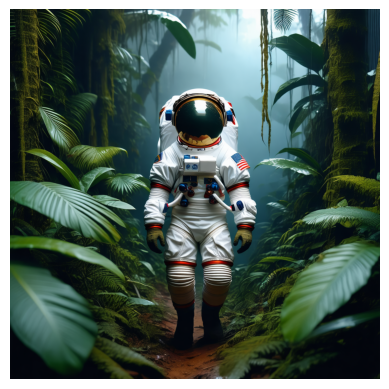

Generating image for prompt: a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 0_sdxl_3_5_a_girl_smiling__Tristan_Eaton__victo_ngai__artgerm.png (generation time: 23.07 sec)


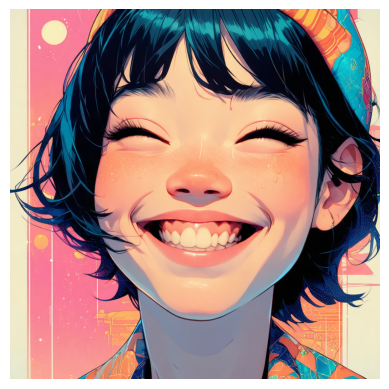

Generating image for prompt: a character portrait of a cyborg super saiyan in the style of moebius in the style of yoji shinkawa trending on artstation deviantart pinterest detailed realistic hd 8 k high resolution


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 1_sdxl_3_5_a_character_portrait_of_a_cyborg_super_saiyan_in_t.png (generation time: 23.29 sec)


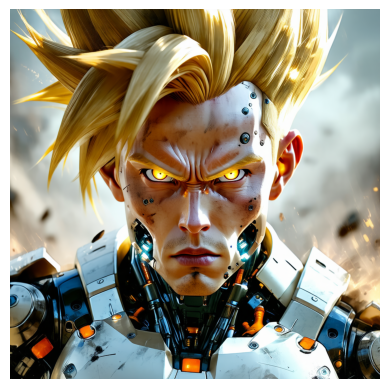

Generating image for prompt: big hand holding skull and bones, illustrated by Simon Stålenhag and Gaston Bussiere, intricate, ultra detailed, photorealistic, trending on artstation


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 2_sdxl_3_5_big_hand_holding_skull_and_bones__illustrated_by_S.png (generation time: 23.39 sec)


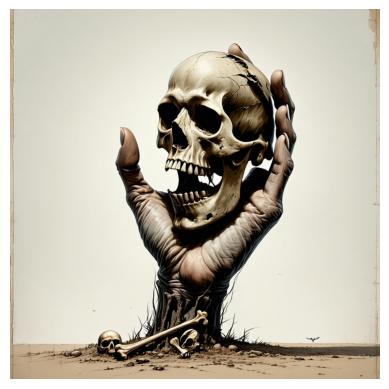

Generating image for prompt: Her huge ominous glowing blue eyes staring into my soul , perfect eyes, soft pale white skin, intricate stunning highly detailed, agostino arrivabene, artgerm, twisted dark lucid dream, 8k portrait render, raven angel wings, swirling thick smoke , beautiful lighting, dark fantasy art, cgsociety


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 3_sdxl_3_5_Her_huge_ominous_glowing_blue_eyes_staring_into_my.png (generation time: 23.47 sec)


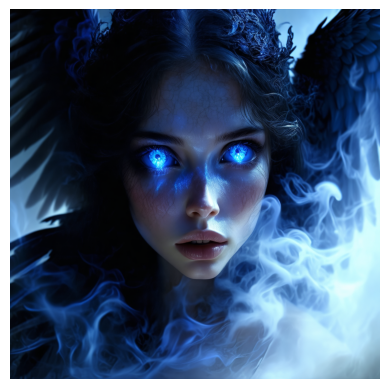

Generating image for prompt: the prince of frost standing alone in his court, archfey, full - body portrait, fantasy, white hair, blue skin, wild eyebrows, young adult, elf, crown, hard edges, soft lighting, professional lighting, trending on artstation


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 4_sdxl_3_5_the_prince_of_frost_standing_alone_in_his_court__a.png (generation time: 23.52 sec)


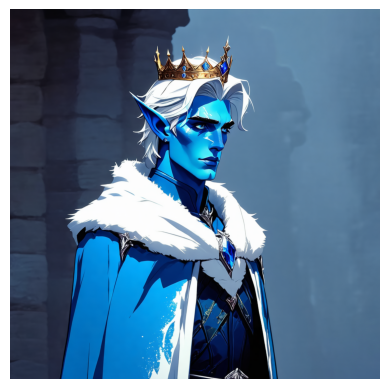

Generating image for prompt: male cottagecore snoop dogg, Calvin Cordozar Broadus Jr., intricate, swagger, highly detailed, digital painting, artstation, concept art, smooth, sharp, focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 5_sdxl_3_5_male_cottagecore_snoop_dogg__Calvin_Cordozar_Broad.png (generation time: 23.56 sec)


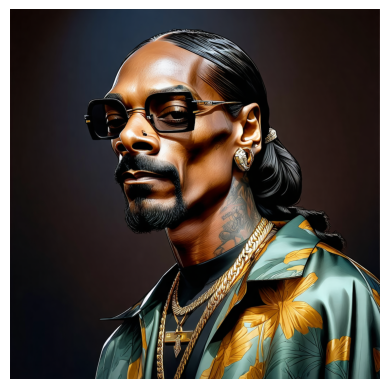

Generating image for prompt: amazing lifelike award winning pencil illustration of bob dylan trending on art station artgerm greg rutkowski alphonse mucha cinematic


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 6_sdxl_3_5_amazing_lifelike_award_winning_pencil_illustration.png (generation time: 23.61 sec)


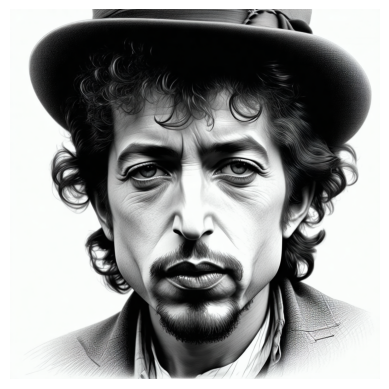

Generating image for prompt: medium - shot vislor turlough played by mark strickson at age 1 8, beautiful, at the alien space pub bar counter, highly detailed, mood lighting, artstation, highly detailed digital painting, smooth, global illumination, fantasy art by greg rutkowsky, karl spitzweg, leyendecker


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 7_sdxl_3_5_medium___shot_vislor_turlough_played_by_mark_stric.png (generation time: 23.66 sec)


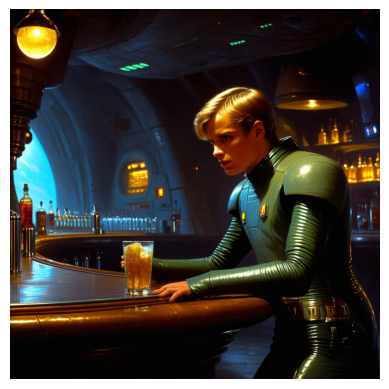

Generating image for prompt: portal to the multiverse of infinite horror with freakish spider creatures leaking out by laurie greasley digital art, highly detailed, intricate, sharp focus, trending on artstation hq, deviantart, octane render, bump map, pinterest, unreal engine 5, 4 k uhd image


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 8_sdxl_3_5_portal_to_the_multiverse_of_infinite_horror_with_f.png (generation time: 23.66 sec)


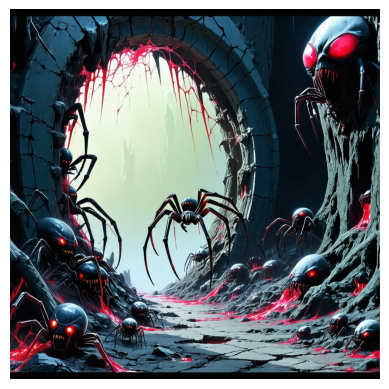

Generating image for prompt: concept art of fractal shaped spaceship by Michal Klimczak, high detail, artstation CG society


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 9_sdxl_3_5_concept_art_of_fractal_shaped_spaceship_by_Michal_.png (generation time: 23.66 sec)


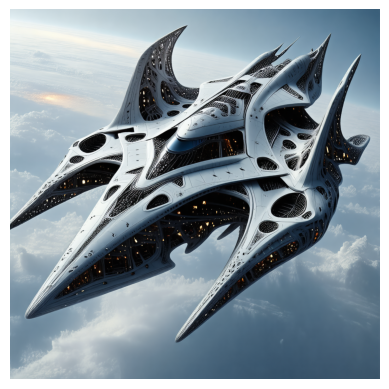

Logs saved to data/sdxl_3_5_inference_logs.csv


In [ ]:
# Run Prompts

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

plt.imshow(image)
image.save("data/test_image.png")
plt.axis('off')  # Hide axes
plt.show()

logs = []

for idx,prompt in enumerate(prompt_list):
    print(f"Generating image for prompt: {prompt}")
    start_time = time.time()
    image = pipe(prompt=prompt).images[0]
    duration = time.time() - start_time

    # Save each image with a unique filename based on the prompt
    safe_prompt = "".join(c if c.isalnum() else "_" for c in prompt)[:50]  # Sanitize
    filename = f"{idx}_sdxl_3_5_{safe_prompt}.png"
    image.save(f"data/{filename}")
    print(f"Saved image to {filename} (generation time: {duration:.2f} sec)")
    
    # Display the image
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

    # Log info
    logs.append({
        "idx": idx,
        "prompt": prompt,
        "filename": filename,
        "duration_sec": duration
    })

# Save logs to CSV
df_logs = pd.DataFrame(logs)
df_logs.to_csv("logs/sdxl_3_5_inference_logs.csv", index=False)
print("Logs saved to logs/sdxl_3_5_inference_logs.csv")

In [9]:
# Delete Model
del pipe
clear_memory()

Cleared memory. Current CPU memory usage: 2449.82 MB, GPU memory usage: 0.00 MB


## Compare Results from SDXL_Turbo, SDXL and SD_3.5 using Inference Times and FID Scores